# Lahore AQI interpolation (OpenAQ v3)

This notebook fetches latest PM2.5 readings from OpenAQ, rolls them up by Lahore region, and produces an interpolated AQI heatmap. Split into logical steps for easier reruns.


In [28]:
# --- CONFIG -------------------------------------------------------------------
SHAPEFILE_PATH = "../../data/Lahore UCs/Lahore UC.shp"  # <-- your shapefile
REGION_NAME_FIELD = "UC"                    # <-- the column that names each region
OUTPUT_BASENAME = "lahore_regions_pm25_aqi" # outputs: .geojson, .shp, .png, .csv

CITY = "Lahore"           # context only
NEAREST_MAX_KM = 10       # nearest-station radius for region rollups

# 12-month window for monthly averages (inclusive months)
MONTHLY_AVG_START = "2024-08-01"
MONTHLY_AVG_END   = "2025-08-31"

# --- Heatmap / interpolation settings -----------------------------------------
GRID_RES_M = 300          # ~pixel size (meters). 200–500 is good for city maps
HEATMAP_DISCRETE_AQI = False  # True = EPA class colors; False = continuous cmap
PNG_DPI   = 220

# Preferred method: 'rbf' (smooth). Fallback to 'idw' if SciPy RBF unavailable.
INTERP_METHOD = "rbf"
IDW_POWER = 1.5           # smoother than 2.0
IDW_KNN   = 20            # use k nearest sensors per grid cell
INNER_BUFFER_M = 1.0 * GRID_RES_M  # shrink mask slightly to avoid edge artifacts
# ------------------------------------------------------------------------------


In [29]:
import os
import json
import math
import time

import requests
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union

OPENAQ_BASE = "https://api.openaq.org/v3"
PARAMETER_ID_PM25 = 2  # PM2.5 parameter id in v3

# NOTE: hardcoded here because that's how your sample was set up; consider env var in production.
API_KEY = "ecaa5acc9069aa0e5e9a98f47986be6dc1a617266203286abaee34ae5169528b"

# ---------- HTTP helper --------------------------------------------------------
def _openaq_get(path, params=None):
    if not API_KEY:
        raise RuntimeError(
            "Missing OPENAQ_API_KEY. Get one from OpenAQ Explorer and set it in the environment."
        )
    headers = {"X-API-Key": API_KEY}
    r = requests.get(f"{OPENAQ_BASE}{path}", params=params or {}, headers=headers, timeout=60)
    r.raise_for_status()
    return r.json()


In [30]:
# ---------- Sensor-scoped monthly averages -----------------------------------
def fetch_pm25_monthly_avg_via_sensor(sensor_id, start_date, end_date, sleep_s=0.15):
    # Calls /v3/sensors/{sensor_id}/days/monthly?date_from&date_to to retrieve
    # monthly means, then returns the average across months in the window.
    # Returns: (monthly_values_list, monthly_avg_over_months, n_months_used)
    page = 1
    limit = 100
    vals = []

    while True:
        payload = _openaq_get(
            f"/sensors/{sensor_id}/days/monthly",
            params={
                "date_from": start_date,
                "date_to": end_date,
                "limit": limit,
                "page": page,
            },
        )
        results = payload.get("results", [])
        if not results:
            break

        for rec in results:
            v = rec.get("value")
            if v is not None:
                vals.append(v)

        meta = payload.get("meta", {})
        found = int(meta.get("found") or 0)
        if page * limit >= found:
            break
        page += 1
        time.sleep(sleep_s)

    if not vals:
        return ([], float("nan"), 0)

    s = pd.Series(vals, dtype="float64")
    return (vals, float(s.mean()), int(s.notna().sum()))


In [31]:
# ---------- Location metadata helpers ----------------------------------------
def fetch_location_core(loc_id):
    # Returns a dict with provider, owner, coordinates for a location id.
    # Keys: provider, owner, coordinates -> (lat, lon) or None
    payload = _openaq_get(f"/locations/{loc_id}")
    results = payload.get("results", [])
    if not results:
        return {"provider": None, "owner": None, "coordinates": None}
    loc = results[0]
    provider = (loc.get("provider") or {}).get("name") or (loc.get("provider") or {}).get("id")
    owner = (loc.get("owner") or {}).get("name") or (loc.get("owner") or {}).get("id")
    coords = (loc.get("coordinates") or {})
    lat = coords.get("latitude")
    lon = coords.get("longitude")
    coordinates = (lat, lon) if (lat is not None and lon is not None) else None
    return {"provider": provider, "owner": owner, "coordinates": coordinates}


def fetch_location_instruments(loc_id):
    # Returns list of instrument names/ids for a location.
    out = []
    try:
        payload = _openaq_get(f"/locations/{loc_id}/instruments")
        for inst in payload.get("results", []):
            name = inst.get("name")
            if not name:
                brand = inst.get("manufacturer")
                model = inst.get("model")
                name = " ".join([p for p in [brand, model] if p])
            if name:
                out.append(str(name))
    except Exception:
        pass
    return sorted(list({x for x in out if x}))


def fetch_location_sensors(loc_id):
    # Returns list of sensors' parameter labels at a location.
    out = []
    try:
        payload = _openaq_get(f"/locations/{loc_id}/sensors")
        for s in payload.get("results", []):
            param = (s.get("parameter") or {}).get("name") or (s.get("parameter") or {}).get("displayName")
            if param:
                out.append(str(param))
    except Exception:
        pass
    return sorted(list({x for x in out if x}))


In [32]:
# ---------- Discovery: latest PM2.5 points, keeping sensor_id ------------------
def fetch_openaq_pm25_v3(bbox=None, limit=1000, sleep_s=0.15):
    # Returns GeoDataFrame of latest PM2.5 readings (v3) within a bbox.
    # Columns: ['location','location_id','sensor_id','latitude','longitude','value','unit','measured_at','geometry']
    if bbox is None:
        raise ValueError("bbox is required for v3 workflow (string: 'minLon,minLat,maxLon,maxLat').")

    # 1) Fetch locations with PM2.5 sensors inside bbox
    page = 1
    loc_rows = []
    while True:
        payload = _openaq_get(
            "/locations",
            params={
                "bbox": bbox,
                "parameters_id": PARAMETER_ID_PM25,
                "limit": min(100, limit),
                "page": page,
            },
        )
        results = payload.get("results", [])
        if not results:
            break
        for loc in results:
            loc_rows.append({
                "locationsId": loc.get("id"),
                "location_name": loc.get("name"),
            })
        meta = payload.get("meta", {})
        found = meta.get("found") or 0
        if page * min(100, limit) >= int(found):
            break
        page += 1
        time.sleep(sleep_s)

    if not loc_rows:
        gdf = gpd.GeoDataFrame(
            pd.DataFrame(columns=[
                "location","location_id","sensor_id","latitude","longitude","value","unit","measured_at"
            ]),
            geometry=[],
            crs="EPSG:4326",
        )
        return gdf

    # 2) For each location, list sensors -> keep only PM2.5; take sensor.latest
    all_rows = []
    for rec in loc_rows:
        loc_id = rec["locationsId"]
        loc_name = rec["location_name"]

        sensors_payload = _openaq_get(f"/locations/{loc_id}/sensors")
        for s in sensors_payload.get("results", []):
            param = (s.get("parameter") or {})
            if param.get("id") != PARAMETER_ID_PM25:
                continue
            sensor_id = s.get("id")
            latest = s.get("latest") or {}
            coords = latest.get("coordinates") or {}
            lat = coords.get("latitude")
            lon = coords.get("longitude")
            val = latest.get("value")
            dt  = (latest.get("datetime") or {}).get("utc")
            unit = param.get("units")  # usually "µg/m³"

            if lat is not None and lon is not None and val is not None:
                all_rows.append({
                    "location": loc_name,
                    "location_id": loc_id,
                    "sensor_id": sensor_id,
                    "latitude": lat,
                    "longitude": lon,
                    "value": val,
                    "unit": unit,
                    "measured_at": dt,
                })
        time.sleep(sleep_s)

    if not all_rows:
        gdf = gpd.GeoDataFrame(
            pd.DataFrame(columns=[
                "location","location_id","sensor_id","latitude","longitude","value","unit","measured_at"
            ]),
            geometry=[],
            crs="EPSG:4326",
        )
        return gdf

    df = pd.DataFrame(all_rows)
    gdf = gpd.GeoDataFrame(
        df,
        geometry=[Point(xy) for xy in zip(df["longitude"], df["latitude"])],
        crs="EPSG:4326",
    )
    return gdf


In [33]:
# ---- Helper: PM2.5 (µg/m³) -> US EPA AQI -------------------------------------
PM25_BREAKS = [
    (0.0,   12.0,   0,   50,  "Good"),
    (12.1,  35.4,  51,  100,  "Moderate"),
    (35.5,  55.4, 101,  150,  "Unhealthy for Sensitive Groups"),
    (55.5, 150.4, 151,  200,  "Unhealthy"),
    (150.5,250.4, 201,  300,  "Very Unhealthy"),
    (250.5,350.4, 301,  400,  "Hazardous"),
    (350.5,500.4, 401,  500,  "Hazardous"),
]


def pm25_to_us_epa_aqi(c):
    if pd.isna(c):
        return (math.nan, None)
    for Clow, Chigh, Ilow, Ihigh, cat in PM25_BREAKS:
        if Clow <= c <= Chigh:
            aqi = ((Ihigh - Ilow) / (Chigh - Clow)) * (c - Clow) + Ilow
            return (round(aqi), cat)
    return (500, "Hazardous")


In [34]:
# ---- Load regions -------------------------------------------------------------
os.environ["SHAPE_RESTORE_SHX"] = "YES"
import fiona

with fiona.Env(SHAPE_RESTORE_SHX="YES"):
    regions = gpd.read_file(SHAPEFILE_PATH, engine="fiona")

print("Shapefile columns:", regions.columns.tolist())

if REGION_NAME_FIELD not in regions.columns:
    raise ValueError(f"'{REGION_NAME_FIELD}' not found in shapefile columns: {list(regions.columns)}")

# Ensure region geometries are valid and in WGS84 for API points
regions = regions.copy()
regions["geometry"] = regions["geometry"].buffer(0)  # fix minor invalidities
if regions.crs is None:
    # assume WGS84 if missing; change if you know the CRS
    regions.set_crs(epsg=4326, inplace=True)
regions_wgs84 = regions.to_crs(epsg=4326)


Shapefile columns: ['fid', 'PROVINCE', 'DISTRICT', 'TEHSIL', 'UC', 'UC_C', 'Flood', 'Area', 'TOWN', 'U_R', 'PROVINCE_C', 'DISTRICT_C', 'TEHSIL_C', 'UC_NAME', 'Data_Sourc', 'Level', 'School', 'New_Name', 'Shape_Leng', 'Shape_Area', 'geometry']


In [35]:
# ---- Fetch latest PM2.5 monitors inside bbox ---------------------------------
minx, miny, maxx, maxy = regions_wgs84.total_bounds
bbox = f"{minx:.4f},{miny:.4f},{maxx:.4f},{maxy:.4f}"

points = fetch_openaq_pm25_v3(bbox=bbox, limit=1000)
if points.empty:
    raise RuntimeError("No PM2.5 data returned from OpenAQ for your query. Try adjusting CITY or bbox.")

# Compute AQI at sensor points (for interpolation)
aqi_vals_pts, aqi_cat_pts = zip(*points["value"].apply(pm25_to_us_epa_aqi))
points["aqi"] = aqi_vals_pts
points["aqi_cat"] = aqi_cat_pts

# ---- Strategy A: Points inside regions ---------------------------------------
joined = gpd.sjoin(points, regions_wgs84, how="left", predicate="within")

# Aggregate by region (only where we actually had in-polygon stations)
inpoly = (
    joined.dropna(subset=[REGION_NAME_FIELD])
    .groupby(REGION_NAME_FIELD)
    .agg(pm25_mean=("value","mean"),
         pm25_count=("value","count"),
         pm25_sample_times=("measured_at", lambda s: list(pd.Series(s).dropna().unique())),
         stations=("location", lambda s: sorted(pd.Series(s).dropna().unique().tolist())),
         station_ids=("location_id", lambda s: sorted(pd.Series(s).dropna().unique().tolist())),
         sensor_ids=("sensor_id",  lambda s: sorted(pd.Series(s).dropna().unique().tolist())))
    .reset_index()
)

# ---- Strategy B: For regions with no in-polygon stations, use nearest (<=10 km)
regions_need = regions_wgs84[~regions_wgs84[REGION_NAME_FIELD].isin(inpoly[REGION_NAME_FIELD])].copy()

if not regions_need.empty:
    # Use UTM Zone 43N (covers Lahore) for meter-based distance
    REG_PROJ = "EPSG:32643"
    reg_proj = regions_need.to_crs(REG_PROJ)
    pts_proj = points.to_crs(REG_PROJ)

    nearest = gpd.sjoin_nearest(
        reg_proj, pts_proj,
        how="left", distance_col="dist_m", max_distance=NEAREST_MAX_KM*1000
    )

    near_agg = (
        nearest.dropna(subset=["value"])  # only those where a station was found within radius
        .groupby(REGION_NAME_FIELD)
        .agg(pm25_mean=("value","mean"),
             pm25_count=("value","count"),
             pm25_sample_times=("measured_at", lambda s: list(pd.Series(s).dropna().unique())),
             stations=("location", lambda s: sorted(pd.Series(s).dropna().unique().tolist())),
             station_ids=("location_id", lambda s: sorted(pd.Series(s).dropna().unique().tolist())),
             sensor_ids=("sensor_id",  lambda s: sorted(pd.Series(s).dropna().unique().tolist())),
             nearest_dist_m=("dist_m","min"))
        .reset_index()
    )

    near_agg["source"] = "nearest_within_%dkm" % NEAREST_MAX_KM
    inpoly["source"] = "in_region"
    summary = pd.concat([inpoly, near_agg], ignore_index=True)
else:
    inpoly["source"] = "in_region"
    summary = inpoly


In [36]:
# ---- Build sensor→location map from the points we collected -------------------
sensor_to_loc = {}
if not points.empty:
    for _, r in points.dropna(subset=["sensor_id"]).iterrows():
        sensor_to_loc[r["sensor_id"]] = r.get("location_id")


# ---- Collect per-location metadata & per-sensor 12-month monthly averages ----
def _flatten_id_lists(series_with_lists):
    return sorted({
        x
        for lst in (series_with_lists.dropna().tolist() if hasattr(series_with_lists, "dropna") else [])
        for x in (lst if isinstance(lst, list) else [lst])
        if x is not None
    })


used_station_ids = _flatten_id_lists(summary.get("station_ids", pd.Series([], dtype=object)))
used_sensor_ids  = _flatten_id_lists(summary.get("sensor_ids",  pd.Series([], dtype=object)))

# 1) Location metadata (provider/owner/coordinates/instruments/sensors)
loc_meta = {}
for loc_id in used_station_ids:
    core = fetch_location_core(loc_id)
    instruments = fetch_location_instruments(loc_id)
    sensors_list = fetch_location_sensors(loc_id)
    loc_meta[loc_id] = {
        "provider": core["provider"],
        "owner": core["owner"],
        "coordinates": core["coordinates"],
        "instruments": instruments,
        "sensors": sensors_list,
    }
    time.sleep(0.1)

# 2) Sensor-level monthly avg (Aug 2024 -> Aug 2025)
sensor_monthlies = {}
for sensor_id in used_sensor_ids:
    try:
        _, m_avg, n_months = fetch_pm25_monthly_avg_via_sensor(sensor_id, MONTHLY_AVG_START, MONTHLY_AVG_END)
    except requests.HTTPError:
        # if sensor is missing data/endpoint, keep NaN
        m_avg, n_months = float("nan"), 0
    sensor_monthlies[sensor_id] = {"avg": m_avg, "n": n_months}
    time.sleep(0.1)


/var/folders/80/08nsjy_s5f3brjxw1crm6mbh0000gn/T/ipykernel_61815/2389708219.py:75: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  out.to_file(shp_path)
/Users/ahmed/Library/Python/3.9/lib/python/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'pm25_sample_times' to 'pm25_sampl'
  ogr_write(
/Users/ahmed/Library/Python/3.9/lib/python/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'station_ids' to 'station_id'
  ogr_write(
/Users/ahmed/Library/Python/3.9/lib/python/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'nearest_dist_m' to 'nearest_di'
  ogr_write(
/Users/ahmed/Library/Python/3.9/lib/python/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'coordinates' to 'coordinate'
  ogr_write(
/Users/ahmed/Library/Python/3.9/lib/python/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laun

Saved: lahore_regions_pm25_aqi.geojson and lahore_regions_pm25_aqi.shp
Saved map: lahore_regions_pm25_aqi.png


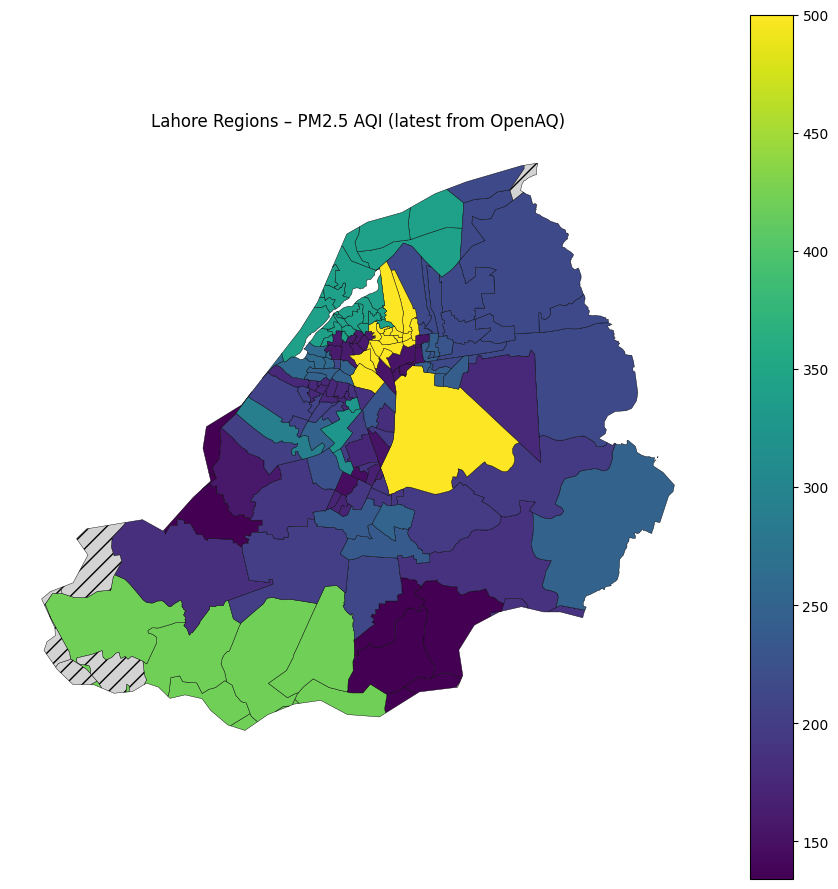

In [37]:
# ---- Region rollup from sensors (monthly avg) + attach location metadata -----
def agg_unique(flat):
    return sorted(list({x for x in flat if pd.notna(x) and x not in [None, "None", "nan"]}))


def region_rollup(row):
    sids = row.get("sensor_ids") or []
    sids = sids if isinstance(sids, list) else [sids]

    providers, owners, coords, insts, sens = [], [], [], [], []
    monthly_avgs, months_counts = [], []

    for sensor_id in sids:
        # monthly avg from sensor
        sm = sensor_monthlies.get(sensor_id, {})
        if not pd.isna(sm.get("avg", float("nan"))):
            monthly_avgs.append(sm["avg"])
            months_counts.append(sm.get("n", 0))

        # attach metadata from its location
        loc_id = sensor_to_loc.get(sensor_id)
        if loc_id is not None:
            meta = loc_meta.get(loc_id, {})
            if meta.get("provider"):
                providers.append(meta["provider"])
            if meta.get("owner"):
                owners.append(meta["owner"])
            if meta.get("coordinates"):
                coords.append(meta["coordinates"])
            if meta.get("instruments"):
                insts.extend(meta["instruments"])
            if meta.get("sensors"):
                sens.extend(meta["sensors"])

    region_monthly_avg = float(pd.Series(monthly_avgs).mean()) if monthly_avgs else float("nan")
    total_months = int(pd.Series(months_counts).sum()) if months_counts else 0

    return pd.Series({
        "providers": agg_unique(providers),
        "owners": agg_unique(owners),
        "coordinates": coords,  # keep raw list of (lat, lon)
        "instruments": agg_unique(insts),
        "sensors": agg_unique(sens),
        "pm25_monthly_avg_12mo": region_monthly_avg,
        "pm25_monthly_months_contributing": total_months,
    })


region_rollups = summary.apply(region_rollup, axis=1)
summary = pd.concat([summary, region_rollups], axis=1)

# ---- Attach summary back to regions ------------------------------------------
out = regions_wgs84.merge(summary, on=REGION_NAME_FIELD, how="left")

# ---- Compute AQI per region from mean PM2.5 (latest sample) ------------------
aqi_vals, aqi_cats = [], []
for v in out["pm25_mean"]:
    aqi, cat = pm25_to_us_epa_aqi(v)
    aqi_vals.append(aqi)
    aqi_cats.append(cat)
out["pm25_aqi"] = aqi_vals
out["pm25_aqi_category"] = aqi_cats

# ---- Tidy up some metadata columns -------------------------------------------
out["pm25_unit"] = "µg/m³"
out["notes"] = out["source"].fillna("no_station_within_%dkm" % NEAREST_MAX_KM)

# ---- Save vector outputs -----------------------------------------------------
# GeoJSON
geojson_path = f"{OUTPUT_BASENAME}.geojson"
out.to_file(geojson_path, driver="GeoJSON")

# Shapefile (folder of files)
shp_path = f"{OUTPUT_BASENAME}.shp"
out.to_file(shp_path)

print(f"Saved: {geojson_path} and {shp_path}")

# ---- Optional quick-look choropleth (regions) --------------------------------
try:
    import matplotlib.pyplot as plt

    fig = plt.figure(figsize=(9, 9))
    ax = plt.gca()
    out.plot(
        column="pm25_aqi",
        legend=True,
        ax=ax,
        edgecolor="black",
        linewidth=0.3,
        missing_kwds={"color":"lightgrey","hatch":"//","label":"No data"},
    )
    ax.set_title("Lahore Regions – PM2.5 AQI (latest from OpenAQ)")
    ax.set_axis_off()
    png_path = f"{OUTPUT_BASENAME}.png"
    plt.tight_layout()
    plt.savefig(png_path, dpi=180)
    print(f"Saved map: {png_path}")
except Exception as e:
    print("Skipping region choropleth render:", e)


RBF interpolation unavailable, falling back to IDW: Matrix is singular.
Saved continuous heatmap: lahore_regions_pm25_aqi_continuous_aqi_heatmap.png
Saved GeoTIFF: lahore_regions_pm25_aqi_continuous_aqi_heatmap.tif


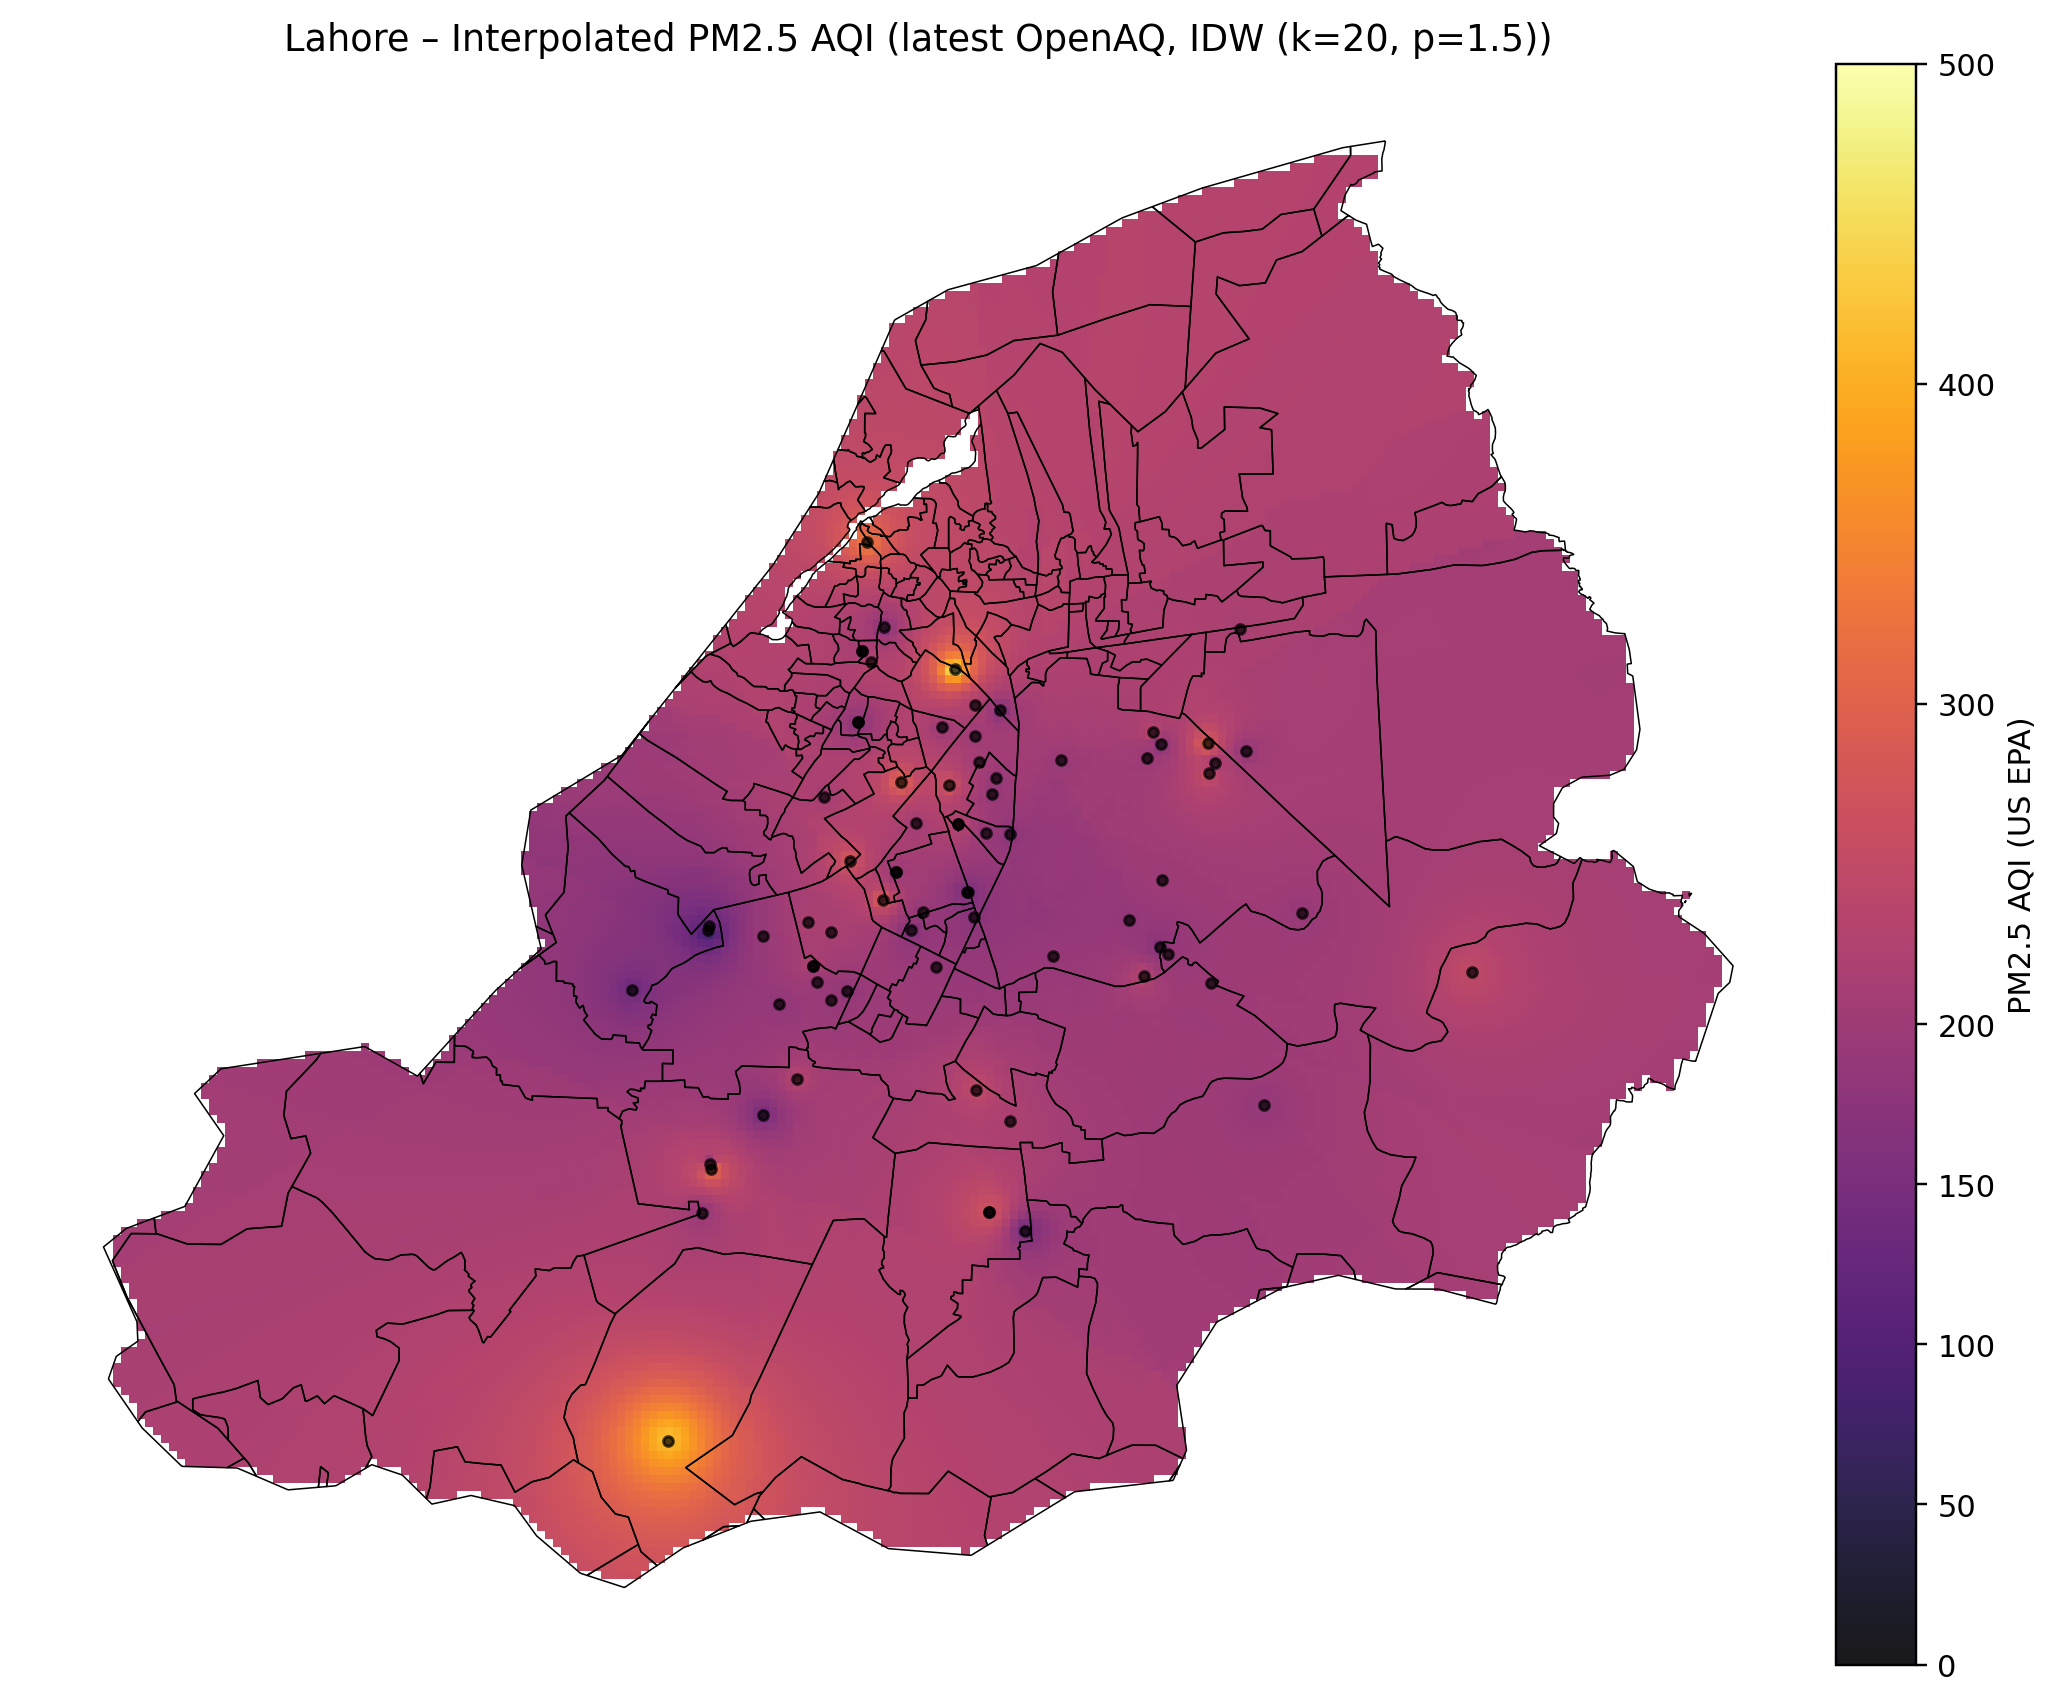

In [38]:
# =============================================================================
# ---- Interpolated continuous heatmap of PM2.5 AQI ----------------------------
# =============================================================================

try:
    import matplotlib.pyplot as plt
    from matplotlib.colors import ListedColormap, BoundaryNorm

    REG_PROJ = "EPSG:32643"  # UTM 43N for Lahore (meters)
    regions_proj = regions_wgs84.to_crs(REG_PROJ)
    points_proj = points.to_crs(REG_PROJ)

    # Union polygon & slightly shrink to reduce edge extrapolation
    union_geom = unary_union(regions_proj.geometry)
    try:
        inner_mask_poly = union_geom.buffer(-INNER_BUFFER_M)
        if inner_mask_poly.is_empty:
            inner_mask_poly = union_geom  # fallback if buffer collapses
    except Exception:
        inner_mask_poly = union_geom

    # Grid strictly inside the (shrunken) mask bbox
    minx, miny, maxx, maxy = inner_mask_poly.bounds
    xs = np.arange(minx, maxx, GRID_RES_M)
    ys = np.arange(miny, maxy, GRID_RES_M)
    XX, YY = np.meshgrid(xs, ys)

    # Sensor coordinates / AQI values
    px = points_proj.geometry.x.values
    py = points_proj.geometry.y.values
    pv = points["aqi"].astype(float).values

    # ---- Interpolation (prefer RBF, fallback to IDW) -------------------------
    Z = np.full(XX.shape, np.nan, dtype=float)
    used_method = None
    if INTERP_METHOD.lower() == "rbf":
        try:
            from scipy.interpolate import Rbf
            # epsilon ~ typical spacing; estimate from bbox & station count
            avg_spacing = max((maxx - minx), (maxy - miny)) / max(len(pv), 2)
            epsilon = max(300.0, avg_spacing)  # meters
            rbf = Rbf(px, py, pv, function="multiquadric", epsilon=epsilon)
            Z = rbf(XX, YY)
            used_method = "RBF (multiquadric)"
        except Exception as e_rbf:
            print("RBF interpolation unavailable, falling back to IDW:", e_rbf)

    if used_method is None:
        try:
            from scipy.spatial import cKDTree
            tree = cKDTree(np.c_[px, py])
            k = min(IDW_KNN, len(px))
            dist, idx = tree.query(np.c_[XX.ravel(), YY.ravel()], k=k)
            dist = np.atleast_2d(dist)
            idx  = np.atleast_2d(idx)
            with np.errstate(divide='ignore'):
                w = 1.0 / (dist ** IDW_POWER)
            # exact hits (distance 0): set weight to a big number so they dominate
            w[np.isinf(w)] = 1e12
            vals_knn = pv[idx]
            num = np.nansum(w * vals_knn, axis=1)
            den = np.nansum(w, axis=1)
            Z = (num / den).reshape(XX.shape)
            used_method = f"IDW (k={k}, p={IDW_POWER})"
        except Exception as e_idw:
            # Last-resort simple (slow) IDW
            print("IDW via cKDTree failed, using simple numpy loop:", e_idw)
            for i in range(XX.shape[0]):
                for j in range(XX.shape[1]):
                    d = np.hypot(px - XX[i, j], py - YY[i, j])
                    w = 1.0 / np.maximum(d, 1e-6) ** IDW_POWER
                    Z[i, j] = np.sum(w * pv) / np.sum(w)
            used_method = f"IDW-simple (p={IDW_POWER})"

    # ---- Strict mask: keep only values inside the (original) union polygon ---
    def mask_outside(poly, XX, YY, batch=200000):
        mask = np.zeros(XX.size, dtype=bool)
        coords = np.c_[XX.ravel(), YY.ravel()]
        n = coords.shape[0]
        for s in range(0, n, batch):
            e = min(n, s+batch)
            pts = gpd.GeoSeries(gpd.points_from_xy(coords[s:e,0], coords[s:e,1]), crs=REG_PROJ)
            mask[s:e] = pts.within(poly).values
        return mask.reshape(XX.shape)

    inside_mask = mask_outside(union_geom, XX, YY)
    Z_masked = np.where(inside_mask, Z, np.nan)

    # Clip to valid AQI range
    Z_masked = np.clip(Z_masked, 0, 500)

    # ---- Styling --------------------------------------------------------------
    if HEATMAP_DISCRETE_AQI:
        aqi_bounds = [0, 50, 100, 150, 200, 300, 400, 500]
        aqi_colors = ["#00e400", "#ffff00", "#ff7e00", "#ff0000", "#8f3f97", "#7e0023", "#7e0023"]
        cmap = ListedColormap(aqi_colors)
        norm = BoundaryNorm(aqi_bounds, cmap.N)
        cb_ticks = aqi_bounds
        cb_label = "PM2.5 AQI (US EPA)"
    else:
        cmap = plt.cm.inferno  # or 'magma', 'plasma', 'turbo'
        norm = plt.Normalize(vmin=0, vmax=500)
        cb_ticks = [0, 50, 100, 150, 200, 300, 400, 500]
        cb_label = "PM2.5 AQI (US EPA)"

    # ---- Plot heatmap ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 10), dpi=PNG_DPI)
    extent = (xs.min(), xs.max(), ys.min(), ys.max())  # projected meters
    im = ax.imshow(
        Z_masked,
        extent=extent,
        interpolation="nearest",
        cmap=cmap,
        norm=norm,
        origin="lower",
        alpha=0.9,
    )

    # Boundaries & stations
    regions_proj.boundary.plot(ax=ax, linewidth=0.5, edgecolor="black")
    points_proj.plot(ax=ax, color="black", markersize=10, alpha=0.7)

    cb = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.01, ticks=cb_ticks)
    cb.set_label(cb_label)
    ax.set_title(f"Lahore – Interpolated PM2.5 AQI (latest OpenAQ, {used_method})")
    ax.set_axis_off()
    heat_png = f"{OUTPUT_BASENAME}_continuous_aqi_heatmap.png"
    plt.tight_layout()
    plt.savefig(heat_png, dpi=PNG_DPI)
    print(f"Saved continuous heatmap: {heat_png}")

    # ---- Optional: export GeoTIFF if rasterio is installed -------------------
    try:
        import rasterio
        from rasterio.transform import from_origin
        transform = from_origin(xs.min(), ys.max(), GRID_RES_M, GRID_RES_M)
        tiff_path = f"{OUTPUT_BASENAME}_continuous_aqi_heatmap.tif"
        with rasterio.open(
            tiff_path, "w",
            driver="GTiff",
            height=Z_masked.shape[0],
            width=Z_masked.shape[1],
            count=1,
            dtype=rasterio.float32,
            crs=REG_PROJ,
            transform=transform,
            nodata=np.nan,
        ) as dst:
            # rasterio expects top-left origin; flip vertically
            dst.write(np.flipud(Z_masked).astype(np.float32), 1)
        print(f"Saved GeoTIFF: {tiff_path}")
    except Exception as e_rt:
        print("GeoTIFF export skipped (install rasterio to enable):", e_rt)

except Exception as e:
    print("Failed to render interpolated heatmap:", e)


In [ ]:
# ---- Also export a flat table CSV for non-GIS use -----------------------------
# - Includes 12-month monthly avg over Aug-2024..Aug-2025 (equal-weighted months, then equal-weighted across sensors)
# - providers / owners / coordinates / instruments / sensors (list-like fields JSON-encoded)
cols = [
    REGION_NAME_FIELD,
    "pm25_mean", "pm25_unit", "pm25_aqi", "pm25_aqi_category", "pm25_count",
    "pm25_monthly_avg_12mo", "pm25_monthly_months_contributing",
    "source", "notes",
    "stations", "providers", "owners", "coordinates", "instruments", "sensors",
]
for c in ["stations","providers","owners","coordinates","instruments","sensors","pm25_sample_times"]:
    if c in out.columns:
        out[c] = out[c].apply(lambda x: x if isinstance(x, list) else ([] if pd.isna(x) else [x]))


tab = out[cols].sort_values(by=REGION_NAME_FIELD)
csv_path = f"{OUTPUT_BASENAME}.csv"

tab_for_csv = tab.copy()
for c in ["stations","providers","owners","coordinates","instruments","sensors"]:
    tab_for_csv[c] = tab_for_csv[c].apply(lambda v: json.dumps(v, ensure_ascii=False))

tab_for_csv.to_csv(csv_path, index=False)
print(f"Saved table to: {csv_path}")


Saved table: lahore_regions_pm25_aqi.csv
